<a href="https://www.kaggle.com/code/jeffbutt/cifake-cnn-resnet-prototype?scriptVersionId=322340212" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CIFAKE Real vs AI-Generated Image Classifier

This notebook builds a binary image classifier for the CIFAKE dataset using a simple CNN baseline and a smaller ResNet-style CNN.

The goal is not to claim a production-ready deepfake detector. CIFAKE images are low-resolution, dataset-specific examples, so the model should be evaluated as a controlled benchmark and app prototype rather than a general internet-image detector.

The notebook focuses on the parts that matter for a credible prototype:

- explicit train/validation/test separation
- stratified validation splitting
- baseline model before a more complex architecture
- validation-based model selection
- threshold tuning without touching the test set
- final test evaluation only after modeling decisions are locked
- saved model artifacts and inference metadata

The key modeling decision is whether the ResNet-style model improves enough over the baseline CNN to justify the extra complexity.

## 1. Setup

Import the core libraries and fix random seeds.

The seed does not make GPU training perfectly deterministic, but it reduces run-to-run noise enough for notebook-level comparison.

In [1]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from PIL import Image

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-26 17:58:34.812505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779818315.047790      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779818315.113842      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779818315.628684      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779818315.628771      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779818315.628774      23 computation_placer.cc:177] computation placer alr

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

In [6]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 2. Configuration

Centralize paths, image size, batch size, training limits, and model flags.

CIFAKE images are 32×32, so the model intentionally stays small. A much larger architecture would be easier to overfit and would not necessarily prove better generalization.

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# Kaggle dataset path
DATASET_DIR = Path("/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images")

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "models"
REPORT_DIR = WORK_DIR / "reports"
PRED_DIR = WORK_DIR / "predictions"

for d in [MODEL_DIR, REPORT_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [9]:
# CIFAKE images are natively 32x32.
IMG_SIZE = 32
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

In [10]:
# Keep these reasonable for Kaggle GPU. Increase if you want to push performance.
SIMPLE_CNN_EPOCHS = 10
RESNET_EPOCHS = 30

In [11]:
# Run both models so the notebook can prove whether the ResNet-style model adds value.
RUN_SIMPLE_CNN_BASELINE = True
RUN_RESNET_MODEL = True

In [12]:
# Optional test-time augmentation. Leave off for the main clean evaluation.
RUN_TTA = False

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = ["REAL", "FAKE"]
LABEL_TO_ID = {"REAL": 0, "FAKE": 1}
ID_TO_LABEL = {0: "REAL", 1: "FAKE"}

In [14]:
print("Dataset directory:", DATASET_DIR)
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Dataset directory: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
Train directory exists: True
Test directory exists: True


## 3. GPU and Mixed Precision

Use mixed precision when a compatible Kaggle GPU is available.

The final output layer remains `float32` because binary probability outputs can become less stable when the last activation runs in reduced precision.

In [15]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)

    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled:", mixed_precision.global_policy())
    except Exception as e:
        print("Mixed precision not enabled:", e)
else:
    print("No GPU found. This notebook will run more slowly on CPU.")

GPU memory growth enabled.
Mixed precision enabled: <DTypePolicy "mixed_float16">


## 4. Build Image Manifest

Create an explicit file-level manifest before building TensorFlow datasets.

This is more reliable than relying only on directory-based splitting because it allows the class balance to be inspected directly and makes the train/validation split auditable.

In [16]:
def build_manifest(split_name, directory):
    rows = []
    valid_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    
    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")
    
    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue
        
        label = class_dir.name.upper()
        if label not in LABEL_TO_ID:
            print(f"Skipping unexpected class folder: {class_dir}")
            continue
        
        for ext in valid_exts:
            for path in class_dir.glob(ext):
                rows.append({
                    "source_split": split_name,
                    "label": label,
                    "label_id": LABEL_TO_ID[label],
                    "path": str(path)
                })
    
    return pd.DataFrame(rows)

In [17]:
train_full_df = build_manifest("train", TRAIN_DIR)
test_df = build_manifest("test", TEST_DIR)

df = pd.concat([train_full_df, test_df], ignore_index=True)

print("Full manifest shape:", df.shape)
display(df.head())
print("\nCounts by source split and label:")
display(pd.crosstab(df["source_split"], df["label"]))

Full manifest shape: (120000, 4)


,source_split,label,label_id,path
0,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
1,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
2,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
3,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
4,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...



Counts by source split and label:


label,FAKE,REAL
source_split,,
test,10000,10000
train,50000,50000


## 5. Stratified Train/Validation Split

Split the training data into train and validation sets using stratification.

This is a required check for this project. If the validation set does not contain both REAL and FAKE examples in the right proportions, validation AUC, F1, precision, and recall become misleading.

The test set remains untouched until the final model and threshold have already been selected.

In [18]:
train_df, val_df = train_test_split(
    train_full_df,
    test_size=VALIDATION_SPLIT,
    stratify=train_full_df["label_id"],
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "validation": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(split_summary)

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    labels_present = sorted(part["label_id"].unique().tolist())
    assert labels_present == [0, 1], f"{name} split is invalid. It does not contain both classes: {labels_present}"

print("All splits contain both classes.")

,train,validation,test
label,,,
FAKE,45000,5000,10000
REAL,45000,5000,10000


All splits contain both classes.


## 6. Basic Dataset Checks

Before training, verify the basic dataset assumptions:

- both classes are present
- class counts are reasonably balanced
- image paths load correctly
- sample images match the expected labels

This is intentionally lightweight. For a larger or less curated dataset, this section should be expanded to include duplicates, corruption checks, source leakage, compression artifacts, and near-duplicate train/test overlap.

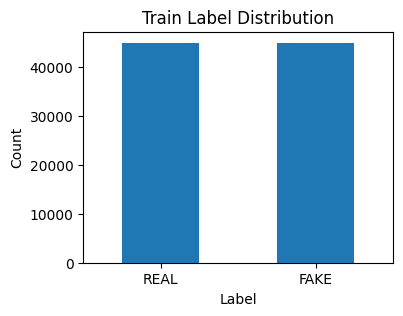

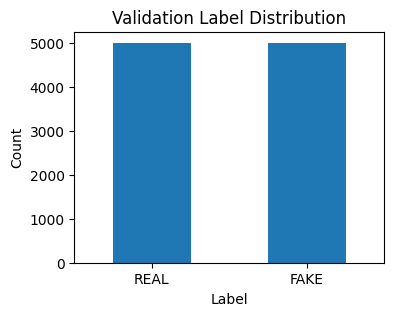

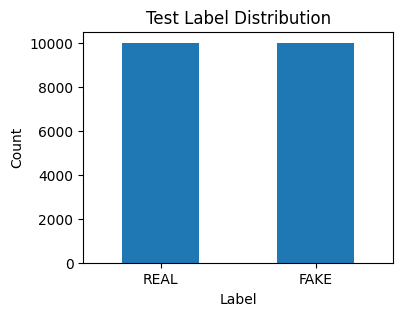

In [19]:
def plot_label_counts(dataframes):
    for name, part in dataframes.items():
        counts = part["label"].value_counts().reindex(CLASS_NAMES)
        plt.figure(figsize=(4, 3))
        counts.plot(kind="bar")
        plt.title(f"{name} Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Count")
        plt.xticks(rotation=0)
        plt.show()

plot_label_counts({"Train": train_df, "Validation": val_df, "Test": test_df})

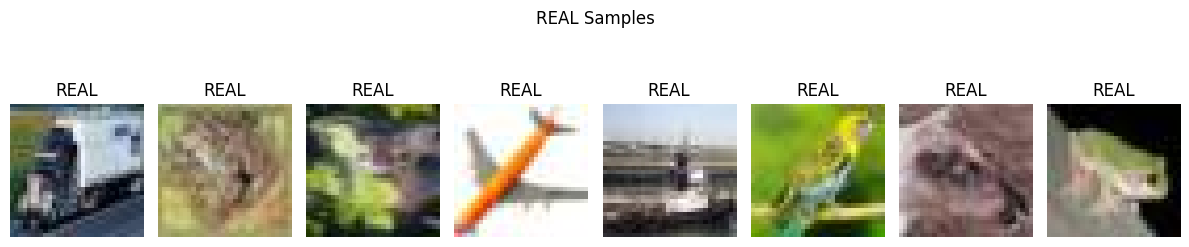

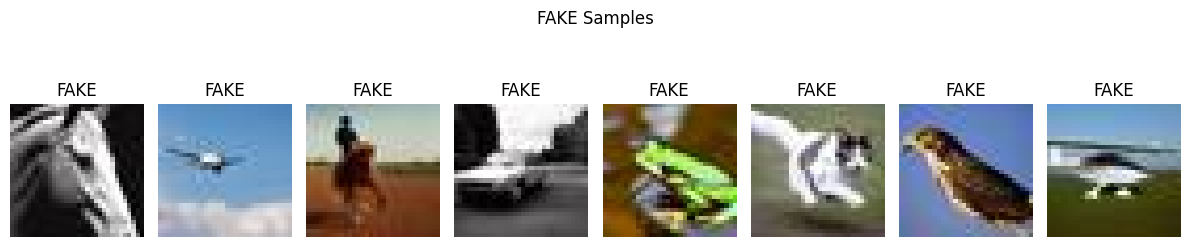

In [20]:
def show_sample_images(part, n=8, title="Sample Images"):
    sample = part.sample(n=min(n, len(part)), random_state=SEED)
    plt.figure(figsize=(12, 3))
    
    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(1, len(sample), i)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_images(train_df[train_df["label"] == "REAL"], n=8, title="REAL Samples")
show_sample_images(train_df[train_df["label"] == "FAKE"], n=8, title="FAKE Samples")

## 7. TensorFlow Dataset Pipeline

Build TensorFlow datasets from the manifest.

Images are loaded as `float32` tensors and scaled to `[0, 1]`. The pipeline uses batching and prefetching so that GPU training is not slowed unnecessarily by image loading.

Augmentation is handled inside the model so it is active during training but automatically disabled during validation, testing, and inference.

In [21]:
def decode_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return img, label

In [22]:
def make_dataset(part, batch_size=BATCH_SIZE, shuffle=False):
    paths = part["path"].values
    labels = part["label_id"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(part), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [23]:
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Pixel range:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

I0000 00:00:1779818349.727895      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (256, 32, 32, 3)
Label batch shape: (256,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>
Pixel range: 0.0 1.0


## 8. Data Augmentation

Use light augmentation only.

CIFAKE images are small, and the signal may depend on subtle texture or artifact patterns. Heavy augmentation could erase the very differences the model needs to learn.

Chosen augmentations:

- horizontal flip
- small translation
- small rotation
- slight zoom
- mild contrast adjustment

Avoid aggressive crops because the images are already only 32×32.

In [24]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.05),
    ],
    name="light_augmentation"
)

In [25]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.08),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 9. Build Models

Train two models instead of assuming the more complex model is better.

### Baseline CNN

The baseline CNN establishes how much signal can be captured with a straightforward convolutional model. If this model performs nearly as well as the ResNet-style model, the simpler model may be preferable for deployment.

### Small ResNet-Style CNN

The ResNet-style model adds residual connections to improve feature learning while keeping the architecture small enough for 32×32 images.

The decision rule is practical: use the ResNet-style model only if it improves validation performance enough to justify the added complexity.

In [26]:
def build_simple_cnn(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    return keras.Model(inputs, outputs, name="simple_cnn_cifake")

In [27]:
def residual_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x
    
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

In [28]:
def build_small_resnet(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    
    x = residual_block(x, 128, stride=2, dropout_rate=0.10)
    x = residual_block(x, 128, stride=1, dropout_rate=0.10)
    
    x = residual_block(x, 256, stride=2, dropout_rate=0.15)
    x = residual_block(x, 256, stride=1, dropout_rate=0.15)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    return keras.Model(inputs, outputs, name="small_resnet_cifake")

## 10. Training Utilities

Use callbacks to control training and reduce unnecessary overfitting.

Validation AUC is used for checkpointing because this is a binary classification problem where ranking quality matters, not just accuracy at a fixed threshold.

Early stopping prevents the model from continuing to train after validation performance stops improving. Learning-rate reduction gives the optimizer a chance to refine the model before training stops.

In [29]:
def compile_binary_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

In [30]:
def make_callbacks(model_name):
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            min_delta=0.0005,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_delta=0.0005,
            min_lr=1e-6,
            verbose=1
        ),
    ]

In [31]:
def plot_history(history, title_prefix="Model"):
    hist = pd.DataFrame(history.history)
    display(hist.tail())
    
    for metric in ["loss", "accuracy", "auc"]:
        plt.figure(figsize=(7, 4))
        plt.plot(hist[metric], label=f"train_{metric}")
        val_metric = f"val_{metric}"
        if val_metric in hist:
            plt.plot(hist[val_metric], label=val_metric)
        plt.title(f"{title_prefix}: {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.show()

## 11. Train Simple CNN Baseline

Train the simpler CNN first.

This provides a reference point for the project. A baseline is important because a deeper model only matters if it beats a simpler one on validation data, not just because it looks more advanced.

Model: "simple_cnn_cifake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10


I0000 00:00:1779818361.511854      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7870 - auc: 0.8706 - loss: 0.4369 - precision: 0.7952 - recall: 0.7714
Epoch 1: val_auc improved from -inf to 0.85003, saving model to /kaggle/working/models/simple_cnn_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 257s 677ms/step - accuracy: 0.7871 - auc: 0.8707 - loss: 0.4367 - precision: 0.7953 - recall: 0.7716 - val_accuracy: 0.6250 - val_auc: 0.8500 - val_loss: 1.0040 - val_precision: 0.5726 - val_recall: 0.9860 - learning_rate: 0.0010
Epoch 2/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8764 - auc: 0.9484 - loss: 0.2905 - precision: 0.8796 - recall: 0.8728
Epoch 2: val_auc improved from 0.85003 to 0.95984, saving model to /kaggle/working/models/simple_cnn_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.8765 - auc: 0.9484 - loss: 0.2904 - precision: 0.8796 - recall: 0.8728 - val_accuracy: 0.7794 - val_auc: 0.9598 - val_loss: 0.5191 - val_precision: 0.6972 - val_recall: 0.9878 - learn

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
5,0.925133,0.978332,0.187975,0.926042,0.924067,0.8034,0.974445,0.535591,0.718588,0.9974,0.00030
6,0.927911,0.980248,0.179201,0.928635,0.927067,0.8701,0.980436,0.333475,0.797460,0.9922,0.00030
7,0.932878,0.982526,0.168586,0.934665,0.930822,0.8751,0.982919,0.319682,0.803234,0.9936,0.00009
8,0.934578,0.983000,0.165902,0.935449,0.933578,0.8625,0.981652,0.349645,0.788569,0.9906,0.00009
9,0.935933,0.983464,0.163420,0.937645,0.933978,0.8631,0.981869,0.356385,0.787764,0.9940,0.00009


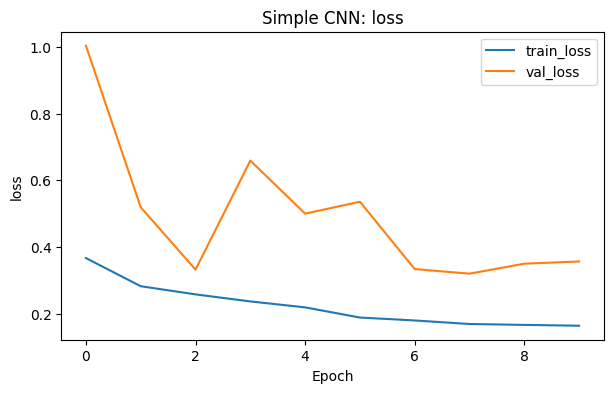

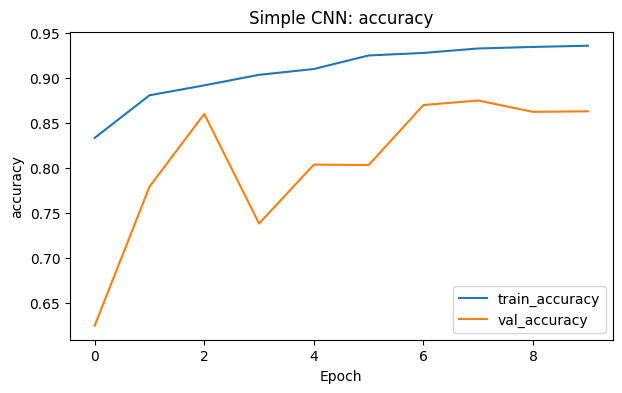

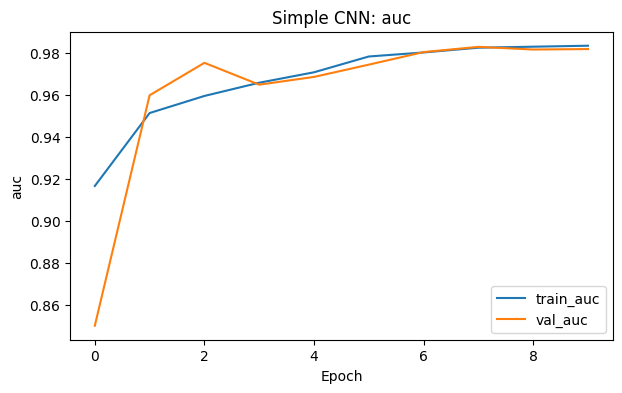

In [32]:
trained_models = {}
histories = {}

if RUN_SIMPLE_CNN_BASELINE:
    simple_cnn = build_simple_cnn(IMG_SIZE)
    compile_binary_model(simple_cnn, learning_rate=1e-3)
    simple_cnn.summary()
    
    simple_history = simple_cnn.fit(
        train_ds,
        validation_data=val_ds,
        epochs=SIMPLE_CNN_EPOCHS,
        callbacks=make_callbacks("simple_cnn_cifake"),
        verbose=1,
    )
    
    histories["simple_cnn"] = simple_history
    trained_models["simple_cnn"] = keras.models.load_model(MODEL_DIR / "simple_cnn_cifake_best.keras")
    plot_history(simple_history, title_prefix="Simple CNN")
else:
    print("Simple CNN baseline skipped.")

## 12. Train Small ResNet-Style CNN

Train the ResNet-style model as the stronger candidate.

The architecture is still intentionally modest. For this dataset, the goal is not maximum depth; the goal is to test whether residual blocks improve validation performance without creating an oversized model for 32×32 inputs.

Model: "small_resnet_cifake"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,728 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,864 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_3[0][

 Total params: 2,846,657 (10.86 MB)

 Trainable params: 2,841,665 (10.84 MB)

 Non-trainable params: 4,992 (19.50 KB)

Epoch 1/30


E0000 00:00:1779818825.256222      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/small_resnet_cifake_1/dropout_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7519 - auc: 0.8288 - loss: 0.5292 - precision: 0.7529 - recall: 0.7522
Epoch 1: val_auc improved from -inf to 0.76555, saving model to /kaggle/working/models/small_resnet_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 93s 197ms/step - accuracy: 0.7521 - auc: 0.8289 - loss: 0.5290 - precision: 0.7531 - recall: 0.7524 - val_accuracy: 0.6944 - val_auc: 0.7655 - val_loss: 0.6723 - val_precision: 0.7167 - val_recall: 0.6430 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8624 - auc: 0.9382 - loss: 0.3179 - precision: 0.8607 - recall: 0.8663
Epoch 2: val_auc improved from 0.76555 to 0.79083, saving model to /kaggle/working/models/small_resnet_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.8624 - auc: 0.9382 - loss: 0.3179 - precision: 0.8607 - recall: 0.8663 - val_accuracy: 0.6021 - val_auc: 0.7908 - val_loss: 2.3719 - val_precision: 0.5573 - val_recall: 0.9926 - 

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
6,0.934733,0.983051,0.165037,0.935469,0.933889,0.8501,0.981069,0.384817,0.771943,0.9938,0.000300
7,0.938189,0.984542,0.157588,0.937732,0.938711,0.8765,0.974691,0.309641,0.811003,0.9818,0.000300
8,0.944933,0.987903,0.138958,0.944578,0.945333,0.9060,0.983450,0.244863,0.850483,0.9852,0.000090
9,0.948178,0.988584,0.134337,0.949176,0.947067,0.8890,0.984087,0.280299,0.822875,0.9914,0.000090
10,0.950067,0.989560,0.128793,0.950267,0.949844,0.9036,0.985441,0.248171,0.845311,0.9880,0.000027


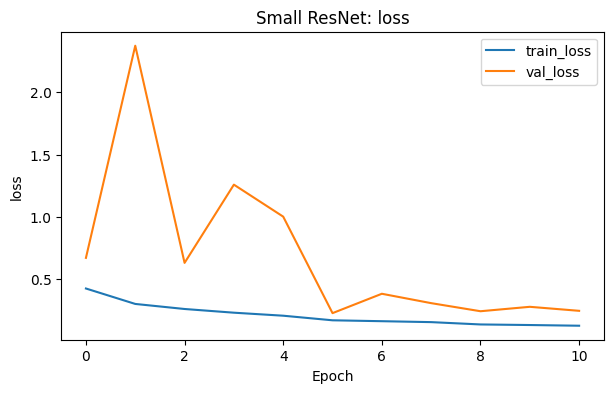

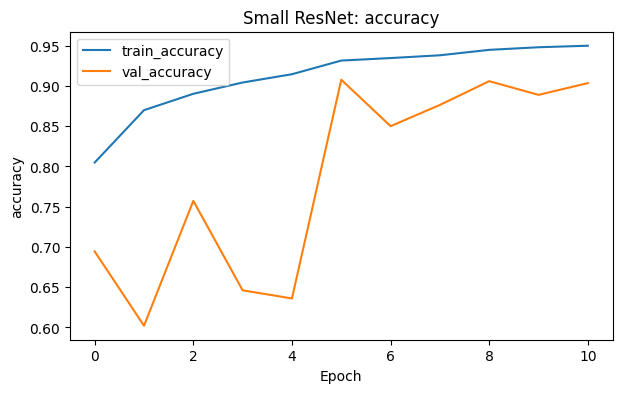

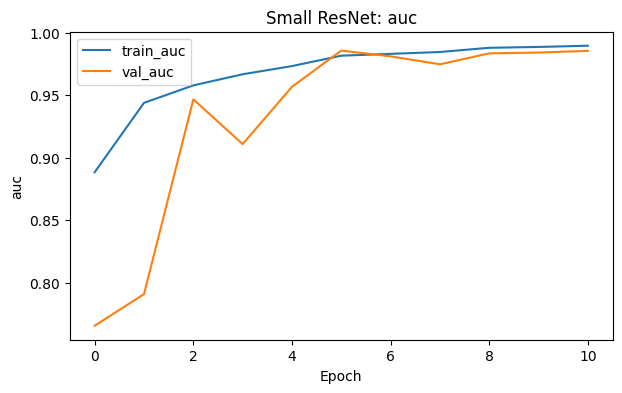

In [33]:
if RUN_RESNET_MODEL:
    small_resnet = build_small_resnet(IMG_SIZE)
    compile_binary_model(small_resnet, learning_rate=1e-3)
    small_resnet.summary()
    
    resnet_history = small_resnet.fit(
        train_ds,
        validation_data=val_ds,
        epochs=RESNET_EPOCHS,
        callbacks=make_callbacks("small_resnet_cifake"),
        verbose=1,
    )
    
    histories["small_resnet"] = resnet_history
    trained_models["small_resnet"] = keras.models.load_model(MODEL_DIR / "small_resnet_cifake_best.keras")
    plot_history(resnet_history, title_prefix="Small ResNet")
else:
    print("Small ResNet model skipped.")

## 13. Evaluation Helpers

Define reusable evaluation functions before comparing models.

Model selection is based only on validation data. The test set is reserved for the final estimate of performance after the model and threshold have been chosen.

In [34]:
def predict_dataset(model, dataset):
    y_true = []
    y_prob = []
    
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().reshape(-1).tolist())
    
    return np.array(y_true).astype(int), np.array(y_prob)

In [35]:
def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

In [36]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, label="Evaluation", verbose=True):
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
    }
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    if verbose:
        print("=" * 80)
        print(label)
        print("=" * 80)
        for k, v in metrics.items():
            if isinstance(v, float):
                print(f"{k}: {v:.4f}")
            else:
                print(f"{k}: {v}")
        
        print("\nClassification Report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            zero_division=0,
        ))
        print("Confusion Matrix:")
        print(cm)
    
    return metrics, cm

## 14. Validation Model Comparison

Compare the trained models on validation data using the default `0.50` threshold.

This comparison answers the first modeling question:

> Does the ResNet-style model outperform the baseline CNN enough to justify using it?

Accuracy is included, but it is not the only decision metric. AUC, precision, recall, and F1 provide a better view of how the model behaves across class boundaries.

In [37]:
val_predictions = {}
val_comparison_rows = []

for model_name, model in trained_models.items():
    y_true, y_prob = predict_dataset(model, val_ds)
    val_predictions[model_name] = {"y_true": y_true, "y_prob": y_prob}
    metrics, _ = evaluate_predictions(
        y_true,
        y_prob,
        threshold=0.5,
        label=f"Validation: {model_name} at 0.50",
        verbose=False,
    )
    metrics["model_name"] = model_name
    val_comparison_rows.append(metrics)

val_comparison_df = pd.DataFrame(val_comparison_rows).sort_values("roc_auc", ascending=False)
display(val_comparison_df)

best_model_name = val_comparison_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

print("Selected model based on validation ROC AUC:", best_model_name)

,label,threshold,accuracy,precision,recall,f1,roc_auc,model_name
1,Validation: small_resnet at 0.50,0.5,0.9078,0.852646,0.9860,0.914487,0.985903,small_resnet
0,Validation: simple_cnn at 0.50,0.5,0.8751,0.803234,0.9936,0.888333,0.985402,simple_cnn


Selected model based on validation ROC AUC: small_resnet


## 15. Threshold Tuning on Validation Data

Tune the classification threshold using validation predictions only.

The default `0.50` threshold is not always the best operating point. For a real application, the threshold should reflect the cost of different mistakes:

- false positive: labeling a real image as AI-generated
- false negative: missing an AI-generated image

This notebook selects the threshold that maximizes validation F1 as a neutral default. The test set is not used during this step.

In [38]:
val_y_true = val_predictions[best_model_name]["y_true"]
val_y_prob = val_predictions[best_model_name]["y_prob"]

thresholds = np.linspace(0.05, 0.95, 181)
threshold_rows = []

for threshold in thresholds:
    y_pred = (val_y_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(val_y_true, y_pred)),
        "precision": float(precision_score(val_y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(val_y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(val_y_true, y_pred, zero_division=0)),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df = threshold_df.sort_values("f1", ascending=False).reset_index(drop=True)

display(threshold_df.head(20))

best_threshold = float(threshold_df.iloc[0]["threshold"])
print("Best validation threshold by F1:", best_threshold)

# Save full threshold table for app/design review.
threshold_path = REPORT_DIR / "validation_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold table to:", threshold_path)

,threshold,accuracy,precision,recall,f1
0,0.800,0.9392,0.927903,0.9524,0.939992
1,0.770,0.9386,0.921407,0.9590,0.939828
2,0.780,0.9387,0.923210,0.9570,0.939802
3,0.785,0.9387,0.923701,0.9564,0.939766
4,0.790,0.9387,0.924521,0.9554,0.939707
5,0.825,0.9392,0.932454,0.9470,0.939671
6,0.805,0.9389,0.928195,0.9514,0.939654
7,0.795,0.9387,0.925840,0.9538,0.939612
8,0.810,0.9389,0.929368,0.9500,0.939571
9,0.820,0.9390,0.931577,0.9476,0.939520


Best validation threshold by F1: 0.7999999999999999
Saved threshold table to: /kaggle/working/reports/validation_threshold_search.csv


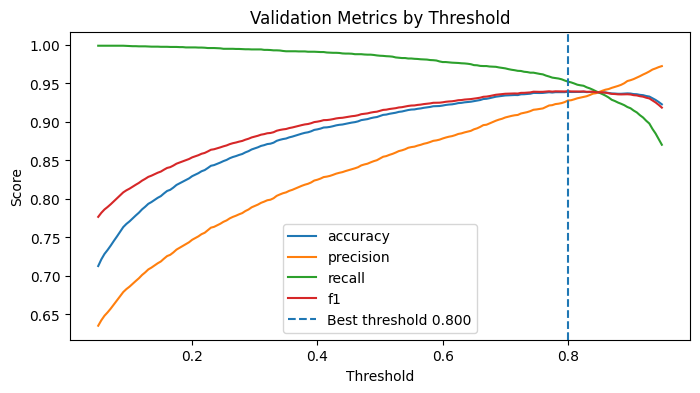

In [39]:
plt.figure(figsize=(8, 4))
for metric in ["accuracy", "precision", "recall", "f1"]:
    plot_df = threshold_df.sort_values("threshold")
    plt.plot(plot_df["threshold"], plot_df[metric], label=metric)

plt.axvline(best_threshold, linestyle="--", label=f"Best threshold {best_threshold:.3f}")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 16. Validation ROC and Precision-Recall Curves

Plot ROC and precision-recall curves for the selected model.

These curves show more than a single accuracy score. They help reveal whether the model separates the classes cleanly or only performs well at one narrow threshold.

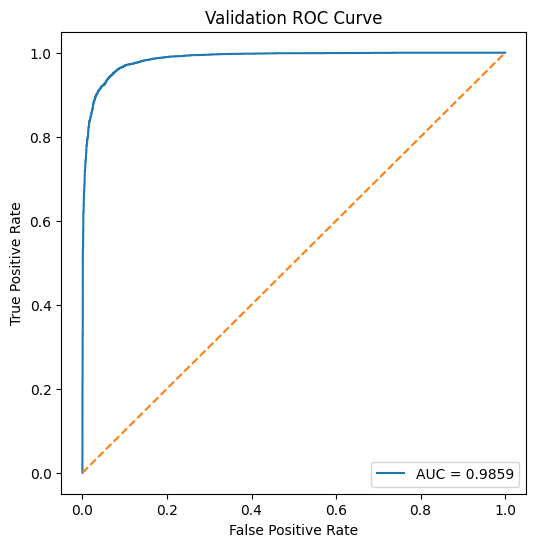

In [40]:
val_auc = safe_roc_auc(val_y_true, val_y_prob)

fpr, tpr, roc_thresholds = roc_curve(val_y_true, val_y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

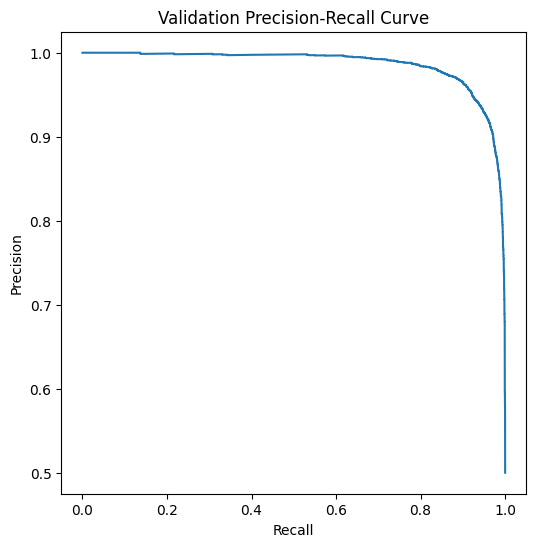

In [41]:
precision, recall, pr_thresholds = precision_recall_curve(val_y_true, val_y_prob)
plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.title("Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 17. Final Test Evaluation

Evaluate the selected model on the test set.

At this point, the model choice and threshold have already been decided using validation data. The test result should therefore be treated as the final held-out estimate, not another tuning signal.

In [42]:
test_y_true, test_y_prob = predict_dataset(best_model, test_ds)

test_metrics_05, test_cm_05 = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=0.5,
    label=f"Test: {best_model_name} at 0.50 Threshold",
)

test_metrics_tuned, test_cm_tuned = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=best_threshold,
    label=f"Test: {best_model_name} at Tuned Threshold {best_threshold:.3f}",
)

Test: small_resnet at 0.50 Threshold
label: Test: small_resnet at 0.50 Threshold
threshold: 0.5000
accuracy: 0.9042
precision: 0.8483
recall: 0.9845
f1: 0.9113
roc_auc: 0.9852

Classification Report:
              precision    recall  f1-score   support

        REAL       0.98      0.82      0.90     10000
        FAKE       0.85      0.98      0.91     10000

    accuracy                           0.90     20000
   macro avg       0.91      0.90      0.90     20000
weighted avg       0.91      0.90      0.90     20000

Confusion Matrix:
[[8239 1761]
 [ 155 9845]]
Test: small_resnet at Tuned Threshold 0.800
label: Test: small_resnet at Tuned Threshold 0.800
threshold: 0.8000
accuracy: 0.9385
precision: 0.9272
recall: 0.9517
f1: 0.9393
roc_auc: 0.9852

Classification Report:
              precision    recall  f1-score   support

        REAL       0.95      0.93      0.94     10000
        FAKE       0.93      0.95      0.94     10000

    accuracy                           0.94     20

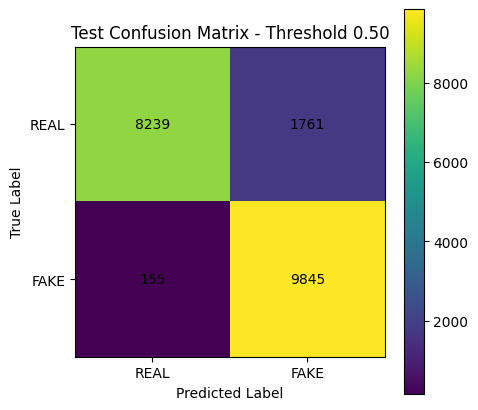

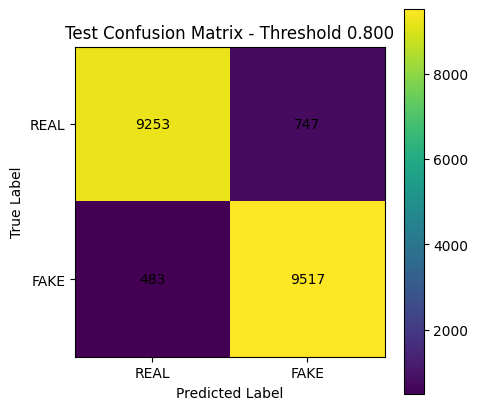

In [43]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES)
    plt.yticks(tick_marks, CLASS_NAMES)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

plot_confusion_matrix(test_cm_05, "Test Confusion Matrix - Threshold 0.50")
plot_confusion_matrix(test_cm_tuned, f"Test Confusion Matrix - Threshold {best_threshold:.3f}")

## 18. Prediction Probability Distribution

Inspect the distribution of predicted probabilities by class.

A useful model should not only produce correct labels; it should also assign probabilities that show meaningful separation between REAL and FAKE examples. Heavy overlap between the two distributions would suggest weak confidence separation even if accuracy appears acceptable.

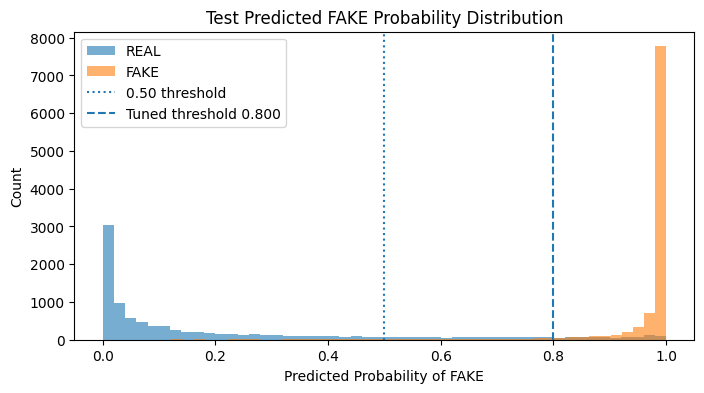

In [44]:
plt.figure(figsize=(8, 4))
plt.hist(test_y_prob[test_y_true == 0], bins=50, alpha=0.6, label="REAL")
plt.hist(test_y_prob[test_y_true == 1], bins=50, alpha=0.6, label="FAKE")
plt.axvline(0.5, linestyle=":", label="0.50 threshold")
plt.axvline(best_threshold, linestyle="--", label=f"Tuned threshold {best_threshold:.3f}")
plt.title("Test Predicted FAKE Probability Distribution")
plt.xlabel("Predicted Probability of FAKE")
plt.ylabel("Count")
plt.legend()
plt.show()

## 19. Row-Level Predictions and Error Analysis

Save row-level predictions and inspect the most confident errors.

This is one of the most important checks in the notebook. Aggregate metrics can hide systematic failure patterns. Confident mistakes are especially useful because they show where the model is wrong despite being certain.

In [45]:
test_results_df = test_df.copy()
test_results_df["true_label_numeric"] = test_y_true
test_results_df["pred_fake_probability"] = test_y_prob
test_results_df["pred_label_numeric"] = (test_results_df["pred_fake_probability"] >= best_threshold).astype(int)
test_results_df["pred_label"] = test_results_df["pred_label_numeric"].map(ID_TO_LABEL)
test_results_df["correct"] = test_results_df["true_label_numeric"] == test_results_df["pred_label_numeric"]

test_results_df["confidence"] = np.where(
    test_results_df["pred_label_numeric"] == 1,
    test_results_df["pred_fake_probability"],
    1 - test_results_df["pred_fake_probability"],
)

test_predictions_path = PRED_DIR / "test_predictions.csv"
test_results_df.to_csv(test_predictions_path, index=False)
print("Saved test predictions to:", test_predictions_path)

display(test_results_df.head())

Saved test predictions to: /kaggle/working/predictions/test_predictions.csv


,source_split,label,label_id,path,true_label_numeric,pred_fake_probability,pred_label_numeric,pred_label,correct,confidence
0,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.994645,1,FAKE,True,0.994645
1,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.999995,1,FAKE,True,0.999995
2,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.995721,1,FAKE,True,0.995721
3,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.883216,1,FAKE,True,0.883216
4,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.982806,1,FAKE,True,0.982806


In [46]:
mistakes_df = test_results_df[~test_results_df["correct"]].copy()
correct_df = test_results_df[test_results_df["correct"]].copy()

print("Mistakes:", len(mistakes_df))
print("Correct:", len(correct_df))

display(mistakes_df.sort_values("confidence", ascending=False).head(20))

Mistakes: 1230
Correct: 18770


,source_split,label,label_id,path,true_label_numeric,pred_fake_probability,pred_label_numeric,pred_label,correct,confidence
19676,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999809,1,FAKE,False,0.999809
14711,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999660,1,FAKE,False,0.999660
18592,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999164,1,FAKE,False,0.999164
12956,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.998849,1,FAKE,False,0.998849
11295,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.998101,1,FAKE,False,0.998101
13023,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.997824,1,FAKE,False,0.997824
12685,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.997624,1,FAKE,False,0.997624
13413,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.997579,1,FAKE,False,0.997579
10549,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.997566,1,FAKE,False,0.997566
12160,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.997496,1,FAKE,False,0.997496


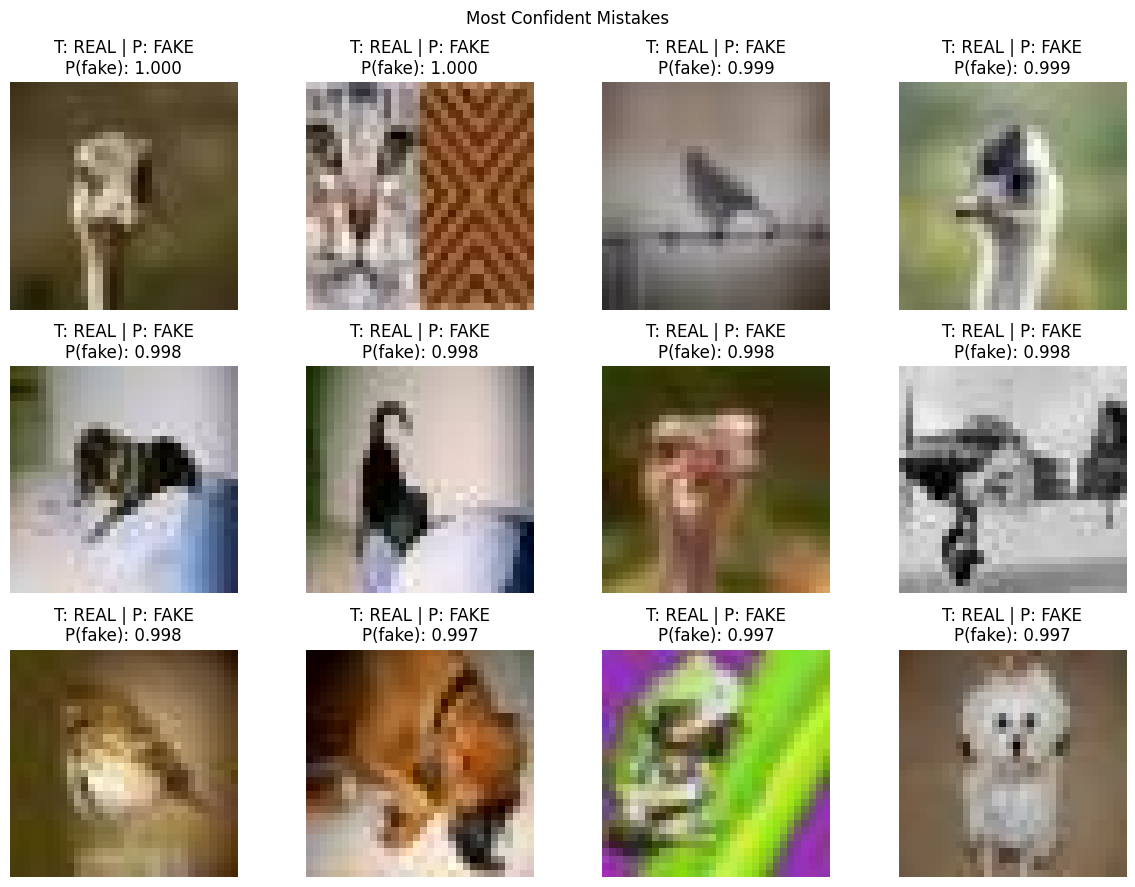

In [47]:
def show_prediction_grid(rows, title, n=12):
    rows = rows.head(n)
    if len(rows) == 0:
        print("No rows to display.")
        return
    
    cols = 4
    rows_n = int(np.ceil(len(rows) / cols))
    plt.figure(figsize=(12, 3 * rows_n))
    
    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(rows_n, cols, i)
        plt.imshow(img)
        plt.title(
            f"T: {row['label']} | P: {row['pred_label']}\nP(fake): {row['pred_fake_probability']:.3f}"
        )
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_prediction_grid(
    mistakes_df.sort_values("confidence", ascending=False),
    title="Most Confident Mistakes",
    n=12,
)

## 20. Optional Test-Time Augmentation

Test-time augmentation averages predictions across the original image and a horizontally flipped version.

This is kept optional. The primary test result should remain simple and reproducible. TTA can be reported as an additional experiment, but it should not replace the main evaluation unless it consistently improves validation and test behavior.

In [48]:
def predict_single_array(model, arr):
    arr = np.expand_dims(arr, axis=0)
    return float(model.predict(arr, verbose=0).reshape(-1)[0])

In [49]:
def predict_single_image_tta(model, image_path):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    prob_original = predict_single_array(model, arr)
    prob_flipped = predict_single_array(model, np.fliplr(arr))
    return (prob_original + prob_flipped) / 2

In [50]:
if RUN_TTA:
    tta_probs = []
    for i, path in enumerate(test_df["path"], start=1):
        tta_probs.append(predict_single_image_tta(best_model, path))
        if i % 1000 == 0:
            print(f"TTA predicted {i}/{len(test_df)}")
    
    tta_probs = np.array(tta_probs)
    evaluate_predictions(
        test_y_true,
        tta_probs,
        threshold=best_threshold,
        label=f"Test with TTA at Threshold {best_threshold:.3f}",
    )
else:
    print("TTA skipped.")

TTA skipped.


## 21. Grad-CAM Sanity Check

Use Grad-CAM to inspect which image regions influence the model.

For 32×32 images, Grad-CAM should be interpreted cautiously. The heatmaps are coarse and should not be treated as definitive explanations. The value here is mainly diagnostic: checking whether the model appears to focus on plausible image regions instead of obvious artifacts, borders, or preprocessing patterns.

In [51]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    return None

last_conv_layer_name = find_last_conv_layer_name(best_model)
print("Last Conv2D layer:", last_conv_layer_name)

Last Conv2D layer: conv2d_17


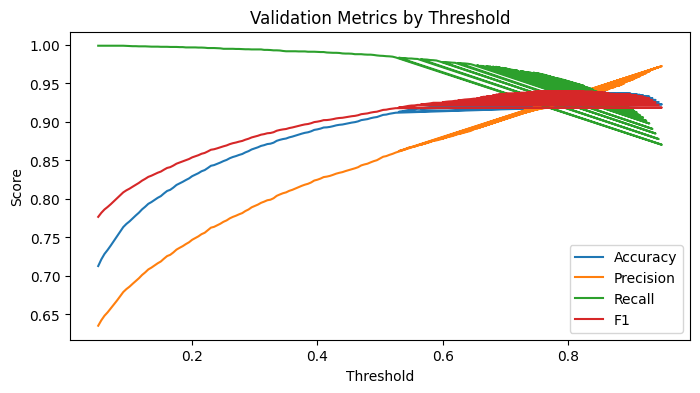

In [52]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [53]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = keras.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        return np.zeros_like(heatmap.numpy())
    
    heatmap = tf.maximum(heatmap, 0) / max_value
    return heatmap.numpy()


def load_image_for_model(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return img, arr


def show_gradcam(path, model, title="Grad-CAM"):
    if last_conv_layer_name is None:
        print("No Conv2D layer found for Grad-CAM.")
        return
    
    img, img_array = load_image_for_model(path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.asarray(heatmap_resized)
    
    plt.figure(figsize=(9, 3))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized)
    plt.title("Heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_resized, alpha=0.45)
    plt.title(title)
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


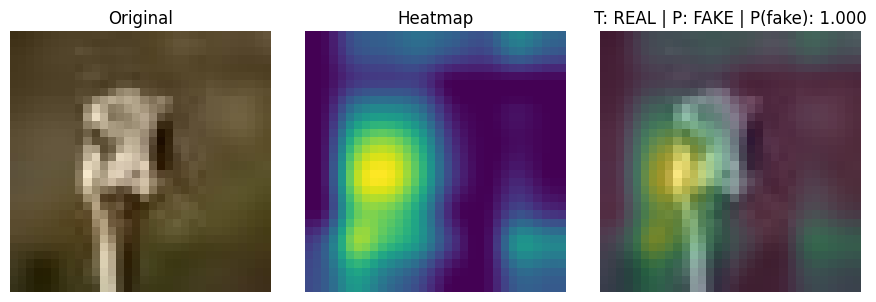

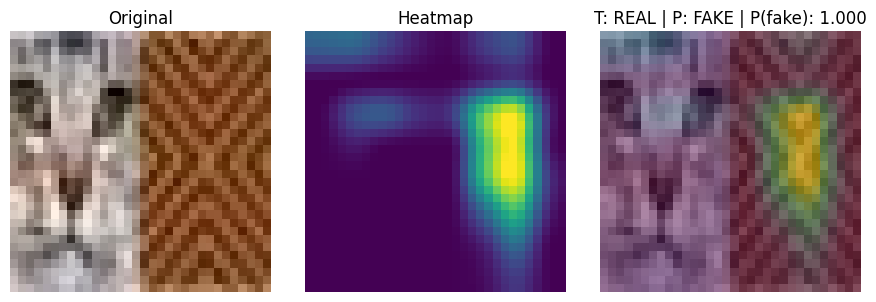

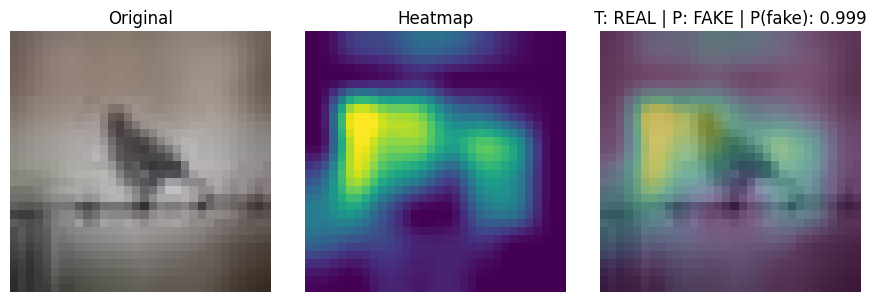

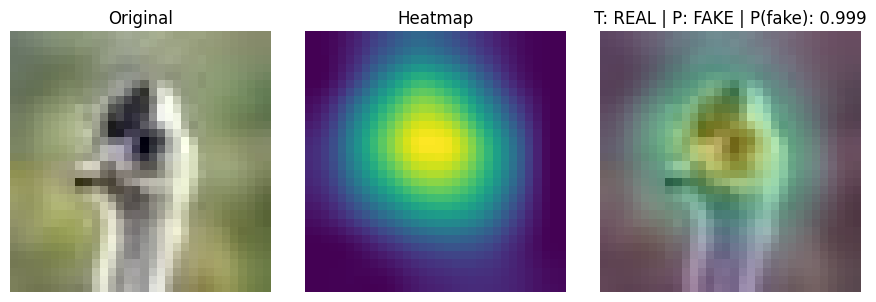

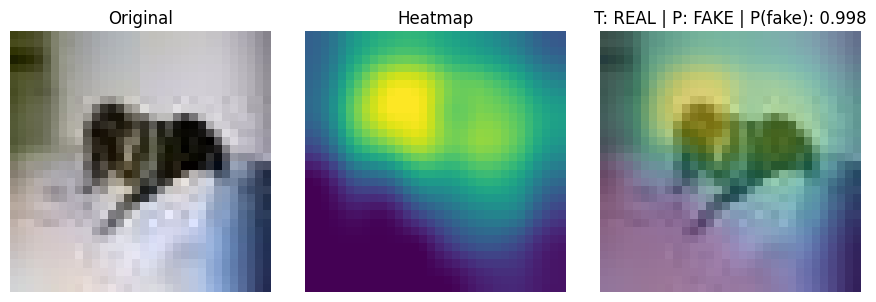

In [54]:
if last_conv_layer_name is not None:
    for _, row in mistakes_df.sort_values("confidence", ascending=False).head(5).iterrows():
        title = f"T: {row['label']} | P: {row['pred_label']} | P(fake): {row['pred_fake_probability']:.3f}"
        show_gradcam(row["path"], best_model, title=title)
else:
    print("Grad-CAM skipped.")

## 22. Save Model Artifacts and Reports

Save the trained model, selected threshold, configuration, metrics, and prediction outputs.

The threshold is saved with the model because it is part of the final classifier. Without the threshold, the model only produces probabilities; it does not fully define the decision rule used in evaluation or deployment.

In [55]:
final_model_path = MODEL_DIR / "cifake_best_model_final.keras"
best_model.save(final_model_path)

app_config = {
    "dataset": "CIFAKE",
    "model_name": best_model_name,
    "model_path": str(final_model_path),
    "image_size": IMG_SIZE,
    "class_mapping": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "default_threshold": 0.5,
    "validation_tuned_threshold": best_threshold,
    "recommended_app_threshold": best_threshold,
    "important_warning": (
        "Prototype trained on CIFAKE-style 32x32 images. Not a general-purpose deepfake detector. "
        "Predictions on out-of-distribution images may be unreliable."
    ),
}

metrics_report = {
    "validation_comparison": val_comparison_df.to_dict(orient="records"),
    "selected_model": best_model_name,
    "test_at_0_5": test_metrics_05,
    "test_at_tuned_threshold": test_metrics_tuned,
    "app_config": app_config,
}

config_path = REPORT_DIR / "app_config.json"
metrics_path = REPORT_DIR / "metrics_report.json"

with open(config_path, "w") as f:
    json.dump(app_config, f, indent=2)

with open(metrics_path, "w") as f:
    json.dump(metrics_report, f, indent=2)

print("Saved model to:", final_model_path)
print("Saved app config to:", config_path)
print("Saved metrics report to:", metrics_path)

Saved model to: /kaggle/working/models/cifake_best_model_final.keras
Saved app config to: /kaggle/working/reports/app_config.json
Saved metrics report to: /kaggle/working/reports/metrics_report.json


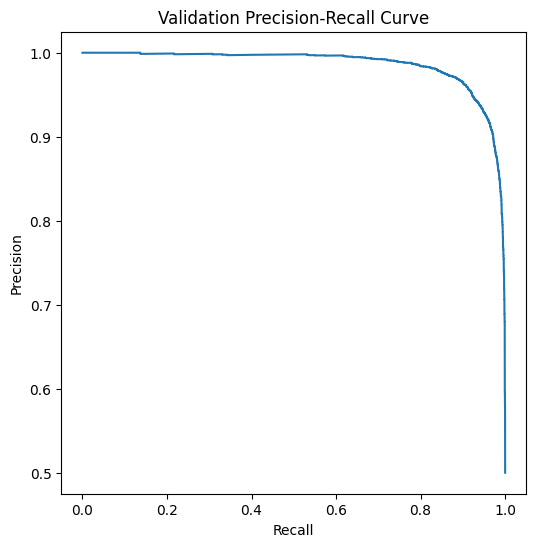

In [56]:
precision, recall, pr_thresholds = precision_recall_curve(val_y_true, val_y_prob)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.title("Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()